# LULC - Train and predict

This notebook trains a random forest model, and then predict LULC.

### Steps: 
1. Train model:
Try one model for all sites. (append all CSVs)
export model dump (python pickle?)
in future we may need to make different models for different regions and year ranges.
train the model using the geomad of the year of the input products.

2. Predict:
per grid tile:
  per year:
    load geomad/indices/elevation etc.
    make using get_gadm (buffered 100m)
    predict
This is as a command. 

### Load packages


In [1]:
# Not sure if this is needed.
# Reload functions during development
%load_ext autoreload
%autoreload 2

In [ ]:
%matplotlib inline

import glob

# Scientific core
import numpy as np
import pandas as pd

# Visualisation
from matplotlib.colors import ListedColormap

# Geospatial
import rioxarray # noqa: F401
import xarray as xr
import zarr # noqa: F401
from ipyleaflet import basemaps
from odc.geo.xr import assign_crs
from pystac.client import Client

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split

# Local
from ldn.typology import classes, colors
from ldn.train_predict import get_geomad_dem_indices, get_buffered_country

In [6]:
class_attr='lulc'

# Gather all of the CSVs of training points for many AOIs.
paths = "*_samples.csv"

# Fiji and Singapore so far.

files = glob.glob(paths)
print(f"Found {len(files)} files: {files}")
samples = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
print(f"Combined training data has {len(samples)} samples.")

samples.drop(columns=["geometry", "outlier"], inplace=True)

samples.head()

Found 2 files: ['Singapore_samples.csv', 'Fiji_samples.csv']
Combined training data has 6352 samples.
Index(['lulc', 'green', 'smad', 'swir16', 'bcmad', 'red', 'blue', 'swir22',
       'nir08', 'emad', 'ndvi', 'ndwi', 'mndwi', 'ndti', 'bsi', 'mbi', 'baei',
       'bui', 'elevation', 'slope', 'aspect'],
      dtype='object')


## Train the model

In [7]:
# Split 70/30 into train/test. Splits the classes into train/test in a representative way.
train_gdf, test_gdf = train_test_split(samples, test_size=0.3, stratify=samples[class_attr], random_state=42)

print(f"Training set class distribution:\n{train_gdf[class_attr].value_counts()}")
print(f"Test set class distribution:\n{test_gdf[class_attr].value_counts()}")
print(train_gdf)

## Create a classifier and fit a model

_classes = train_gdf[class_attr].values.astype(int)
print(f"Classes: {np.unique(_classes)}")

# Observations — drop class and any remaining non-numeric columns
feature_cols = [c for c in train_gdf.columns
                if c != class_attr
                and pd.api.types.is_numeric_dtype(train_gdf[c])]
observations = train_gdf[feature_cols].values

# Create and fit
classifier = RandomForestClassifier(class_weight='balanced')
model = classifier.fit(observations, _classes)
# Define features and target

feature_cols = [c for c in train_gdf.columns if c != class_attr]

X_train = train_gdf[feature_cols].values
y_train = train_gdf[class_attr].values
X_test = test_gdf[feature_cols].values
y_test = test_gdf[class_attr].values

classifier = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42)
model = classifier.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Feature importance
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importances:")
print(importances)
# TODO: Drop noisy features and retrain.

present = np.unique(np.concatenate([y_test, y_pred]))
target_names = [k for k, v in sorted(classes.items(), key=lambda x: x[1]) if v in present]

print(classification_report(y_test, y_pred, target_names=target_names, labels=present))

Training set class distribution:
lulc
1    1598
5    1175
6     453
4     411
2     407
3     402
Name: count, dtype: int64
Test set class distribution:
lulc
1    685
5    504
6    195
4    176
2    174
3    172
Name: count, dtype: int64
      lulc     green      smad    swir16     bcmad       red      blue  \
2313     2  0.070517  0.000424  0.180545  0.015013  0.037187  0.024207   
3472     1  0.063698  0.000866  0.182277  0.051326  0.042027  0.033227   
4981     2  0.056273  0.000907  0.185055  0.030287  0.043513  0.021210   
2518     4  0.041423  0.000578  0.090097  0.020754  0.025472  0.015682   
1710     6  0.089960  0.000718  0.031550  0.033687  0.047720  0.060452   
...    ...       ...       ...       ...       ...       ...       ...   
3537     1  0.040377  0.000157  0.141000  0.018645  0.021127  0.013565   
3363     1  0.028250  0.000309  0.103765  0.014456  0.014637  0.010292   
5654     3  0.072332  0.003258  0.184808  0.045194  0.065870  0.034877   
500      5  0.166822  

In [ ]:
# # Export the model
# import joblib
# joblib.dump(model, "random_forest_model.joblib")

# # Load the model
# model = joblib.load("random_forest_model.joblib")

In [ ]:
# Get geomad dem etc. for the AOI that we want to predict on.

# Use another country to test
country_of_interest = {"Cape Verde": "CPV"}
analysis_crs = 'EPSG:6933' # Equal Earth for global analysis
stac_geoparquet = "https://s3.us-west-2.amazonaws.com/data.ldn.auspatious.com/ausp_ls_geomad/0-0-2/ausp_ls_geomad.parquet"

datetime_year = "2020"
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1/")
wgs84 = 'EPSG:4326' # WGS84

country_wgs84_buffered = get_buffered_country(country_of_interest, wgs84, analysis_crs)

country_wgs84_buffered.explore()

In [14]:
geomad_dem = get_geomad_dem_indices(country_wgs84_buffered, stac_geoparquet, datetime_year, catalog=catalog)
print(geomad_dem)

(-22.96700941678103, 15.972657470507741, -22.65576858321884, 16.232066538301716)
Found 1 GeoMAD items for this region and year
Available bands (excluding count): ['green', 'swir16', 'smad', 'emad', 'red', 'bcmad', 'nir08', 'blue', 'swir22']
GeoMAD dataset loaded CRS (should be native): 6933
GeoMAD bands loaded: ['green', 'swir16', 'smad', 'emad', 'red', 'bcmad', 'nir08', 'blue', 'swir22']
GeoMAD dataset shape: FrozenMappingWarningOnValuesAccess({'y': 1062, 'x': 1002})
Found 2 DEM items for this AOI
<xarray.Dataset> Size: 144MB
Dimensions:      (y: 1061, x: 1001)
Coordinates:
  * y            (y) float64 8kB 2.044e+06 2.044e+06 ... 2.012e+06 2.012e+06
  * x            (x) float64 8kB -2.216e+06 -2.216e+06 ... -2.186e+06 -2.186e+06
    time         datetime64[ns] 8B 2020-01-01
    spatial_ref  int64 8B 0
Data variables: (12/20)
    green        (y, x) float64 8MB nan nan nan nan nan ... nan nan nan nan nan
    swir16       (y, x) float64 8MB nan nan nan nan nan ... nan nan nan nan nan
  

In [ ]:
# test_attr = "elevation"
test_attr = "red"
# test_attr = "ndvi"

geomad_dem[test_attr].odc.explore(
    cmap="YlGn",
    vmin=geomad_dem[test_attr].min().values,
    vmax=geomad_dem[test_attr].max().values,
)

## Predict

              precision    recall  f1-score   support

  Tree Cover       0.99      0.99      0.99       685
   Grassland       0.96      0.90      0.93       174
    Cropland       0.94      0.97      0.96       172
     Wetland       0.99      0.98      0.99       176
    Built-up       0.99      0.99      0.99       504
       Water       0.98      0.98      0.98       195

    accuracy                           0.98      1906
   macro avg       0.97      0.97      0.97      1906
weighted avg       0.98      0.98      0.98      1906



PosixPath('predicted_lulc.tif')

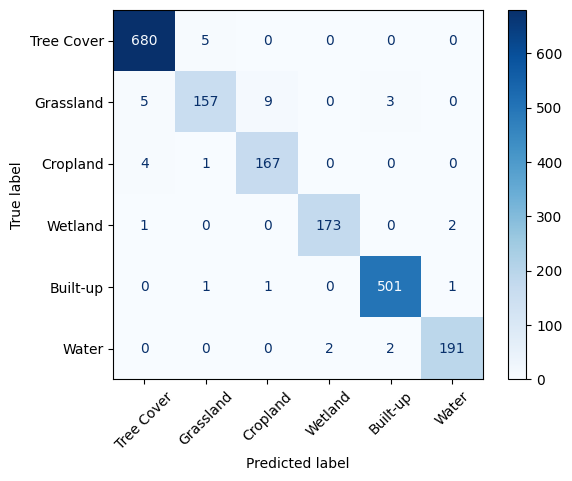

In [ ]:
stack = np.stack([geomad_dem[f].values.flatten() for f in feature_cols], axis=1)
stack = np.stack([geomad_dem[f].values.flatten() for f in feature_cols], axis=1)
stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

predictions = model.predict(stack)

# Reshape back to raster
prediction_map = predictions.reshape(geomad_dem[feature_cols[0]].shape)

# Wrap in DataArray
predicted_da = xr.DataArray(
    prediction_map,
    coords={"y": geomad_dem.y, "x": geomad_dem.x},
    dims=["y", "x"],
    name="lulc",
)

## Visualise our results

predicted_da = assign_crs(predicted_da, crs=analysis_crs)

# Can't use this because there is no Other (7) class in prediction.
# data_classes = sorted(colors.keys())
# print(f"All classes: {data_classes}")
data_classes = [0, 1, 2, 3, 4, 5, 6]
cmap = ListedColormap([colors[c] for c in data_classes])

# Aim for >80% accuracy. Don't just look at the confusion matrix, also look at the output map.

# Use a product for validation.
# One validation method for tuning and another for final measure.

# target_names = [k for k, v in sorted(classes.items(), key=lambda x: x[1]) if v != 0]
target_names = [k for k, v in sorted(classes.items(), key=lambda x: x[1]) if v != 0 and v != 7] # Use this while there is no Other (7) class in the data.

# Classification report
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45, cmap="Blues")

predicted_da.odc.write_cog("predicted_lulc.tif", overwrite=True)

In [22]:
predicted_da.odc.explore(
    classes=data_classes,
    cmap=cmap,
    legend=True,
    tiles=basemaps.Esri.WorldImagery
)